# My ternary spinodal code, developed in steps

Saswata Bhattacharyya

I developed this NumPy code to study ternary spinodal decomposition. I first create a composition field, define its free energy, check the derivatives, and then add the Fourier update. This teaching version follows my Ternary_fastcode notebook. I use the polynomial free energy actually present in that calculation and solve the two coupled gradient terms together.

I assume constant mobility, periodic boundaries and no elasticity. All quantities are dimensionless; no conversion to meters, seconds or joules is supplied. Mole fractions $c_A$, $c_B$ and $c_C$ satisfy $c_A+c_B+c_C=1$. I evolve $c_A$ and $c_B$ and calculate $c_C$ from this constraint. Install `numpy`, `matplotlib` and `jupyter`, then run the cells in order.

## 1. Create the grid and initial compositions

I use 256 points in each direction. The grid spacings dx and dy are one dimensionless length unit. The seed fixes the random starting field. I remove the mean of each small fluctuation so the initial mean of each component is exactly one third to numerical precision. These fluctuations are added only at initialization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Nx = Ny = 256
dx = dy = 1.0
seed = 1234
rng = np.random.RandomState(seed)
noise_A = rng.normal(0.0, 0.001, (Nx, Ny))
noise_B = rng.normal(0.0, 0.001, (Nx, Ny))
cA = 1.0 / 3.0 + noise_A - noise_A.mean()
cB = 1.0 / 3.0 + noise_B - noise_B.mean()
cC = 1.0 - cA - cB
initial_A, initial_B = cA.copy(), cB.copy()
initial_means = np.array([cA.mean(), cB.mean(), cC.mean()])
assert np.max(np.abs(initial_means - 1.0 / 3.0)) < 1e-12
print("Initial mean mole fractions:", initial_means)

Initial mean mole fractions: [0.33333333 0.33333333 0.33333333]


## 2. Write the polynomial free energy

I define the bulk free-energy density as

$$f=A_1c_A^2c_B^2+A_2c_B^2c_C^2+A_3c_A^2c_C^2+B c_A^2c_B^2c_C^2.$$

The coefficients A1, A2, A3 and B are dimensionless free-energy parameters. B is a coefficient, not the mole fraction cB. I use A1 = A2 = A3 = 1 and B = 12 from my notebook. This is a polynomial model, rather than the regular-solution model with logarithms. Its three pure-component corners have zero bulk energy. The total free energy adds kA|∇cA|² + kB|∇cB|² + kC|∇cC|², where kA, kB and kC are dimensionless gradient-energy coefficients.

In [2]:
A1 = A2 = A3 = 1.0
B = 12.0
kA = kB = kC = 1.0
kAA, kBB, kAB = kA + kC, kB + kC, kC

def bulk_energy(a, b):
    c = 1.0 - a - b
    return A1*a**2*b**2 + A2*b**2*c**2 + A3*a**2*c**2 + B*a**2*b**2*c**2

assert bulk_energy(1.0, 0.0) == 0.0
assert bulk_energy(0.0, 1.0) == 0.0
assert bulk_energy(0.0, 0.0) == 0.0
print("Bulk energy at equal composition:", bulk_energy(1/3, 1/3))

Bulk energy at equal composition: 0.053497942386831296


## 3. Differentiate while enforcing the composition constraint

I substitute cC = 1 − cA − cB before differentiating. The derivatives gA = ∂f/∂cA and gB = ∂f/∂cB are diffusion-potential differences relative to C. They are dimensionless here. I compare the analytical expressions with centered finite differences at several compositions before using them in evolution.

In [3]:
def bulk_derivatives(a, b):
    c = 1.0 - a - b
    gA = (2*A1*a*b**2 - 2*A2*b**2*c
          + 2*A3*a*c**2 - 2*A3*a**2*c
          + 2*B*a*b**2*c**2 - 2*B*a**2*b**2*c)
    gB = (2*A1*a**2*b + 2*A2*b*c**2
          - 2*A2*b**2*c - 2*A3*a**2*c
          + 2*B*a**2*b*c**2 - 2*B*a**2*b**2*c)
    return gA, gB

check_points = rng.dirichlet([1, 1, 1], size=100)
a, b = check_points[:, 0], check_points[:, 1]
eps = 1e-6
gA, gB = bulk_derivatives(a, b)
fd_A = (bulk_energy(a+eps, b) - bulk_energy(a-eps, b)) / (2*eps)
fd_B = (bulk_energy(a, b+eps) - bulk_energy(a, b-eps)) / (2*eps)
derivative_error = max(np.max(np.abs(gA-fd_A)), np.max(np.abs(gB-fd_B)))
assert derivative_error < 1e-8
print("Maximum derivative error:", derivative_error)

Maximum derivative error: 1.645147906792488e-11


## 4. Define mobility and check its sign

I write the constant mobility matrix explicitly:

$$L=\begin{pmatrix}M_{AA}&-M_{AB}\\-M_{AB}&M_{BB}\end{pmatrix}.
\qquad \partial_t\mathbf c=\nabla\cdot(L\nabla\boldsymbol\mu).$$

Here the composition vector is (cA,cB), and the diffusion-potential vector is (μA,μB). I retain the original notation MAB = 0.5 as the positive magnitude; the actual off-diagonal entries are −0.5. The mobility coefficients are dimensionless. Positive eigenvalues ensure that the continuum free-energy rate is nonpositive: dF/dt = −∫(∇μ)ᵀL(∇μ) dA. This does not prove stability of a finite time step.

In [4]:
M_AA = M_BB = 1.0
M_AB = 0.5
mobility = np.array([[M_AA, -M_AB], [-M_AB, M_BB]])
assert np.all(np.linalg.eigvalsh(mobility) > 0)
print("Mobility eigenvalues:", np.linalg.eigvalsh(mobility))

Mobility eigenvalues: [0.5 1.5]


## 5. Construct the Fourier wave numbers

I use NumPy's frequency order to construct kx and ky, in inverse dimensionless length units. The quantity k2 = kx² + ky² is the squared wave-number magnitude. k4 = k2². A Fourier Laplacian multiplies by −k2. The gradient contribution contains two Laplacians, so it produces k4. The zero mode has k2 = 0 and must remain unchanged.

In [5]:
kx = 2*np.pi*np.fft.fftfreq(Nx, d=dx)
ky = 2*np.pi*np.fft.fftfreq(Ny, d=dy)
k2 = kx[:, None]**2 + ky[None, :]**2
k4 = k2**2
assert k2[0, 0] == 0.0
assert k2.shape == cA.shape
print("Maximum squared wave number:", k2.max())

Maximum squared wave number: 19.739208802178716


## 6. Solve one coupled time step

I define the gradient-coefficient matrix K with entries kAA, kBB and kAB. Because the gradient energy has no factor one half, μ = g − 2K∇²c. I treat g explicitly and the coupled gradient terms implicitly:

$$[I+2\Delta t\,k^4 LK]\widehat{\mathbf c}^{\,new}
=\widehat{\mathbf c}^{\,old}-\Delta t\,k^2L\widehat{\mathbf g}^{\,old}.$$

The hat denotes the discrete Fourier transform, I is the identity matrix, and dt is the dimensionless time step. I write the two-by-two solution explicitly so both new fields use the same old fields. In my original notebook the second assignment used an already updated first field; this teaching version removes that ordering dependence.

In [6]:
dt = 0.1
K = np.array([[kAA, kAB], [kAB, kBB]])
LK = mobility @ K
H11 = 1 + 2*dt*k4*LK[0, 0]
H12 = 2*dt*k4*LK[0, 1]
H21 = 2*dt*k4*LK[1, 0]
H22 = 1 + 2*dt*k4*LK[1, 1]
determinant = H11*H22 - H12*H21
assert np.all(determinant > 0)

def advance(a, b):
    gA, gB = bulk_derivatives(a, b)
    a_hat, b_hat = np.fft.fft2(a), np.fft.fft2(b)
    gA_hat, gB_hat = np.fft.fft2(gA), np.fft.fft2(gB)
    rhs_A = a_hat - dt*k2*(M_AA*gA_hat - M_AB*gB_hat)
    rhs_B = b_hat - dt*k2*(M_BB*gB_hat - M_AB*gA_hat)
    new_A_hat = (H22*rhs_A - H12*rhs_B) / determinant
    new_B_hat = (H11*rhs_B - H21*rhs_A) / determinant
    return np.fft.ifft2(new_A_hat).real, np.fft.ifft2(new_B_hat).real

one_A, one_B = advance(cA, cB)
assert abs(one_A.mean() - cA.mean()) < 1e-12
assert abs(one_B.mean() - cB.mean()) < 1e-12
print("One-step conservation check passed.")

One-step conservation check passed.


## 7. Repeat the update and measure conservation

I now run 20000 steps, giving a final dimensionless time of 2000, as in my original notebook. For a quick first check, students can reduce steps to 2000. I record the mean and minimum and maximum mole fractions every 100 steps. The polynomial model does not guarantee that every mole fraction stays between zero and one. I report these values and do not clip the evolving fields, because clipping changes component conservation.

In [7]:
steps = 20000
cA, cB = initial_A.copy(), initial_B.copy()
history = []
for n in range(steps + 1):
    if n % 100 == 0 or n == steps:
        cC = 1.0 - cA - cB
        fields = np.array([cA, cB, cC])
        assert np.all(np.isfinite(fields))
        means = fields.mean(axis=(1, 2))
        drift = np.max(np.abs(means - initial_means))
        history.append([n*dt, drift, fields.min(), fields.max()])
    if n < steps:
        cA, cB = advance(cA, cB)
cC = 1.0 - cA - cB
history = np.array(history)
assert history[:, 1].max() < 1e-11
print("Final time:", steps*dt)
print("Maximum mean drift:", history[:, 1].max())
print("Final minimum and maximum:", min(cA.min(), cB.min(), cC.min()), max(cA.max(), cB.max(), cC.max()))

Final time: 2000.0
Maximum mean drift: 9.43689570931383e-16
Final minimum and maximum: -0.0019485726370812584 0.9987217522586989


## 8. Show each composition separately

I plot all three mole fractions with the same color scale. The horizontal axis indexes y and the vertical axis indexes x, following the array convention used above. Separate panels show the continuous compositions rather than assigning every pixel to a phase with a threshold. These images show the simulated state at the stated time; they do not establish equilibrium or connectivity.

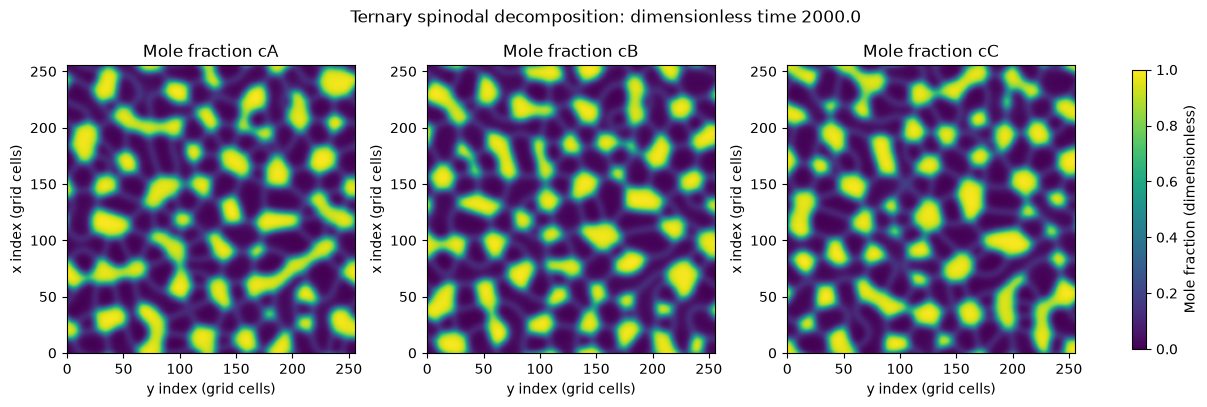

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, field, label in zip(axes, [cA, cB, cC], ["A", "B", "C"]):
    image = ax.imshow(field, origin="lower", vmin=0, vmax=1, cmap="viridis")
    ax.set_title("Mole fraction c" + label)
    ax.set_xlabel("y index (grid cells)")
    ax.set_ylabel("x index (grid cells)")
fig.colorbar(image, ax=axes, label="Mole fraction (dimensionless)", shrink=0.8)
fig.suptitle("Ternary spinodal decomposition: dimensionless time " + str(steps*dt))
plt.show()

## 9. Save the fields for structure and correlation analysis

I save the unmodified compositions and the run settings in a NumPy archive. The structure-function lesson can read any one of these fields, remove its measured mean, and calculate its spectrum and pair correlation. Spatial correlation measures a length and direction of composition variation; it does not by itself prove connectivity. I keep that question separate from Hoshen–Kopelman labeling.

In [9]:
np.savez_compressed("ternary-fields.npz", cA=cA, cB=cB, cC=cC,
                    dx=dx, dy=dy, dt=dt, steps=steps, seed=seed)
with np.load("ternary-fields.npz") as saved:
    assert np.array_equal(saved["cA"], cA)
    deviation = saved["cA"] - saved["cA"].mean()
    structure = np.abs(np.fft.fft2(deviation))**2 / deviation.size
    covariance = np.fft.ifft2(structure).real
    assert abs(covariance[0, 0] - np.mean(deviation**2)) < 1e-12
print("Saved ternary-fields.npz; covariance normalization check passed.")

Saved ternary-fields.npz; covariance normalization check passed.


## What I checked

The cells check the three bulk minima, chemical derivatives against finite differences, mobility eigenvalues, one-step component conservation, finite fields and mean conservation during the run, and covariance normalization of a saved field. These checks do not establish spatial or time-step convergence. I have not claimed unconditional energy stability or an equilibrium morphology.

For the next calculation, use [my structure-function and pair-correlation lesson](https://saswataiith.github.io/resources/structure-correlation/).